Accuracy: 0.9736842105263158

Confusion Matrix:
 [[40  3]
 [ 0 71]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



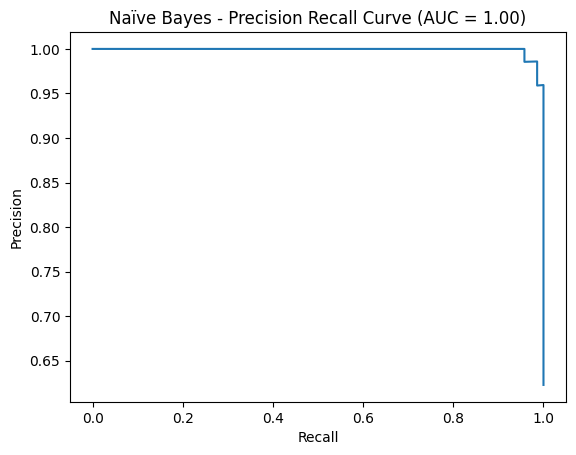

In [1]:
# ==============================
# Experiment 1: Naïve Bayes
# ==============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    auc
)

# 1️⃣ Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# 2️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3️⃣ Train Naïve Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# 4️⃣ Predict
y_pred = nb_model.predict(X_test)
y_prob = nb_model.predict_proba(X_test)[:, 1]

# 5️⃣ Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Naïve Bayes - Precision Recall Curve (AUC = %.2f)" % pr_auc)
plt.show()


Accuracy: 0.9473684210526315

Confusion Matrix:
 [[40  3]
 [ 3 68]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



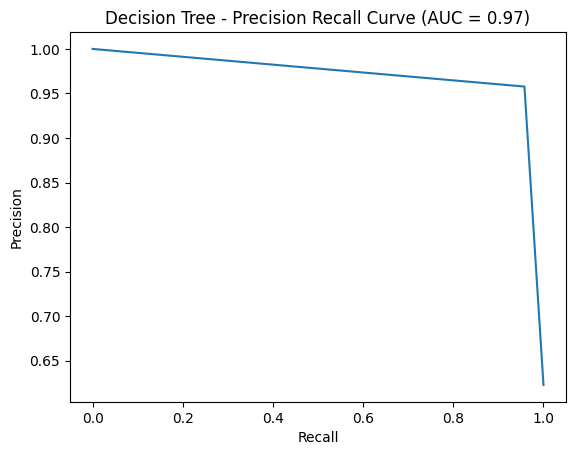

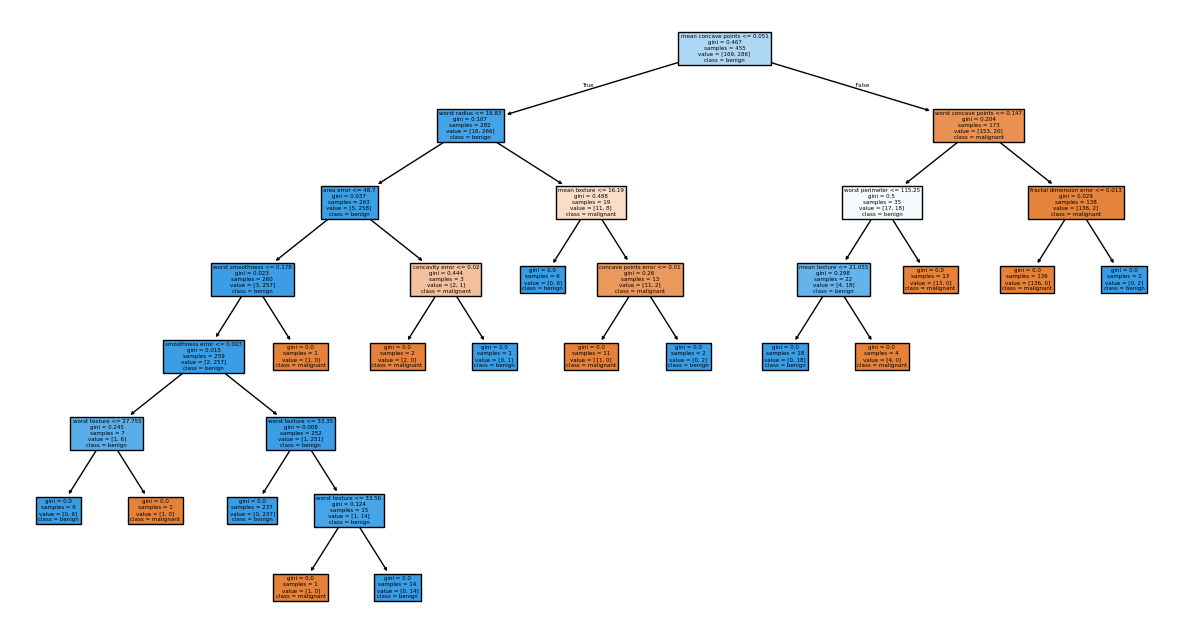

In [2]:
# ==============================
# Experiment 2: Decision Tree
# ==============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    auc
)

# 1️⃣ Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# 2️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3️⃣ Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 4️⃣ Predict
y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:, 1]

# 5️⃣ Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Decision Tree - Precision Recall Curve (AUC = %.2f)" % pr_auc)
plt.show()

# 6️⃣ Visualize Tree
plt.figure(figsize=(15,8))
plot_tree(dt_model, filled=True, feature_names=data.feature_names, class_names=data.target_names)
plt.show()


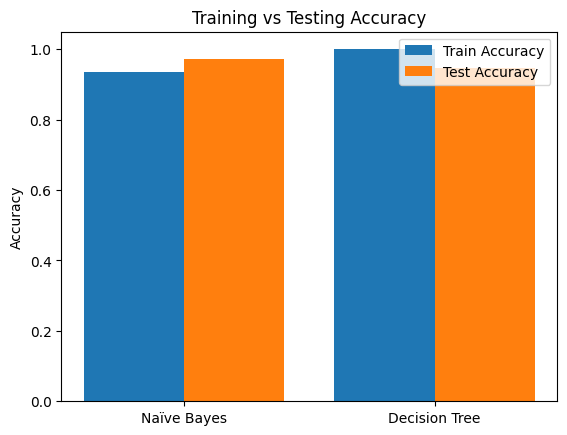

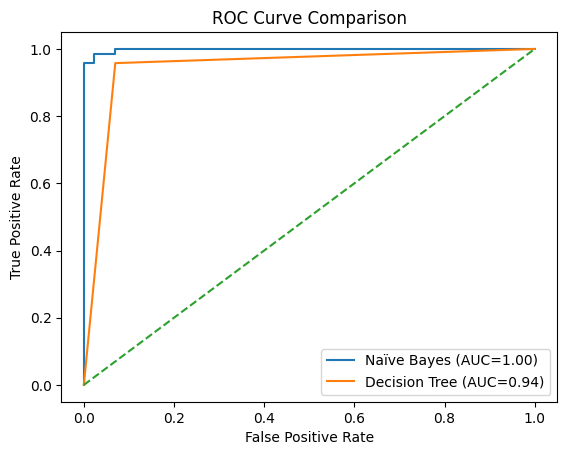

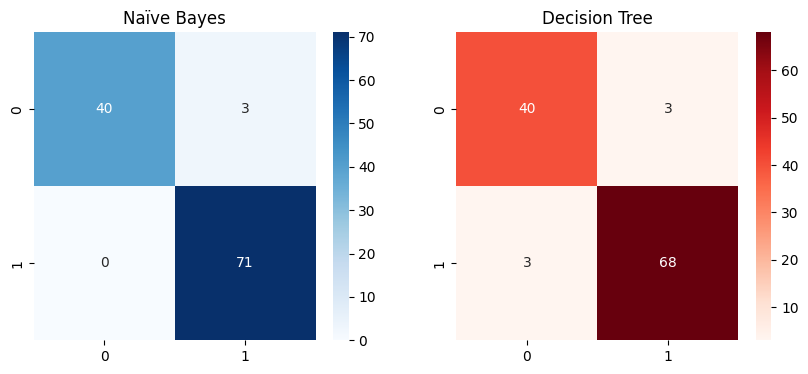

In [3]:
# ==============================
# Experiment 3: Model Comparison
# ==============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# Load data
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train models
nb = GaussianNB()
dt = DecisionTreeClassifier(random_state=42)

nb.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Predictions
nb_train_acc = accuracy_score(y_train, nb.predict(X_train))
nb_test_acc = accuracy_score(y_test, nb.predict(X_test))

dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
dt_test_acc = accuracy_score(y_test, dt.predict(X_test))

# 1️⃣ Bar Chart (Accuracy comparison)

models = ['Naïve Bayes', 'Decision Tree']
train_acc = [nb_train_acc, dt_train_acc]
test_acc = [nb_test_acc, dt_test_acc]

x = np.arange(len(models))

plt.figure()
plt.bar(x - 0.2, train_acc, width=0.4, label='Train Accuracy')
plt.bar(x + 0.2, test_acc, width=0.4, label='Test Accuracy')
plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")
plt.legend()
plt.show()

# 2️⃣ ROC Curve comparison

nb_prob = nb.predict_proba(X_test)[:, 1]
dt_prob = dt.predict_proba(X_test)[:, 1]

nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)

plt.figure()
plt.plot(nb_fpr, nb_tpr, label='Naïve Bayes (AUC=%.2f)' % roc_auc_score(y_test, nb_prob))
plt.plot(dt_fpr, dt_tpr, label='Decision Tree (AUC=%.2f)' % roc_auc_score(y_test, dt_prob))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# 3️⃣ Confusion Matrix Heatmaps

nb_cm = confusion_matrix(y_test, nb.predict(X_test))
dt_cm = confusion_matrix(y_test, dt.predict(X_test))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Naïve Bayes")

plt.subplot(1,2,2)
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Reds')
plt.title("Decision Tree")

plt.show()
